<a href="https://colab.research.google.com/github/kimjehui/DL300/blob/main/part1_ch01_pytorchverson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from torchvision import datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import Image

warnings.filterwarnings('ignore')
%matplotlib inline

SEED = 34
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [17]:
train_ds = datasets.MNIST(root="./data", train=True, download=True)
test_ds  = datasets.MNIST(root="./data", train=False, download=True)

train_images = train_ds.data.numpy()
train_labels = train_ds.targets.numpy()
test_images = test_ds.data.numpy()
test_labels = test_ds.targets.numpy()

In [18]:
print(f"train_images: {train_images.shape}")
print(f"train_labels: {train_labels.shape}")

print(f"test__images: {test_images.shape}")
print(f"test_labels: {test_labels.shape}")

train_images: (60000, 28, 28)
train_labels: (60000,)
test__images: (10000, 28, 28)
test_labels: (10000,)


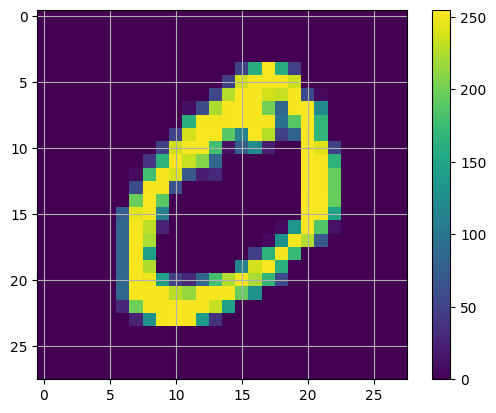

In [6]:
plt.figure()
plt.imshow(train_images[1])
plt.colorbar()
plt.grid(True)
plt.show()

In [7]:
list(filter(lambda x:x != 0, train_images[0].reshape(-1)))[:10]

[np.uint8(3),
 np.uint8(18),
 np.uint8(18),
 np.uint8(18),
 np.uint8(126),
 np.uint8(136),
 np.uint8(175),
 np.uint8(26),
 np.uint8(166),
 np.uint8(255)]

In [19]:
print(max(train_images.reshape(-1)), min(train_images.reshape(-1)))
print(max(test_images.reshape(-1)), min(test_images.reshape(-1)))
min_tr = min(train_images.reshape(-1))
max_tr = max(train_images.reshape(-1))
max_te = max(test_images.reshape(-1))
min_te = min(test_images.reshape(-1))
max_tr

255 0
255 0


np.uint8(255)

In [20]:
test_images= test_images.astype(np.float64)
train_images = train_images.astype(np.float64)

In [21]:
train_images = (train_images - min_tr) / (max_tr - min_tr)
test_images = (test_images - min_te) / (max_te - min_te)

In [22]:
print(list(filter(lambda x: x != 0, train_images[0].reshape(-1)))[:10])
print(list(filter(lambda x: x != 0, train_labels.reshape(-1)))[:10])
print(list(filter(lambda x: x != 0, test_images[0].reshape(-1)))[:10])
print(list(filter(lambda x: x != 0, test_labels.reshape(-1)))[:10])

[np.float64(0.011764705882352941), np.float64(0.07058823529411765), np.float64(0.07058823529411765), np.float64(0.07058823529411765), np.float64(0.49411764705882355), np.float64(0.5333333333333333), np.float64(0.6862745098039216), np.float64(0.10196078431372549), np.float64(0.6509803921568628), np.float64(1.0)]
[np.int64(5), np.int64(4), np.int64(1), np.int64(9), np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(4), np.int64(3)]
[np.float64(0.32941176470588235), np.float64(0.7254901960784313), np.float64(0.6235294117647059), np.float64(0.592156862745098), np.float64(0.23529411764705882), np.float64(0.1411764705882353), np.float64(0.8705882352941177), np.float64(0.996078431372549), np.float64(0.996078431372549), np.float64(0.996078431372549)]
[np.int64(7), np.int64(2), np.int64(1), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(6)]


In [23]:
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
print(train_images.dtype, train_labels.dtype, test_images.dtype, test_labels.dtype)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
float64 int64 float64 int64


In [26]:
train_images[:5].shape

(5, 28, 28)

In [29]:
train_images_tensor = torch.from_numpy(train_images)
train_5ten=train_images_tensor[:5].permute(1,0,2).reshape(28, -1)


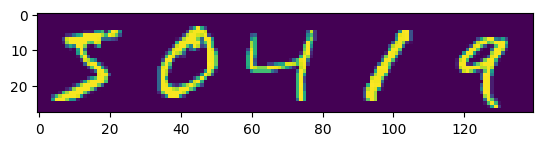

In [30]:
plt.imshow(train_5ten)

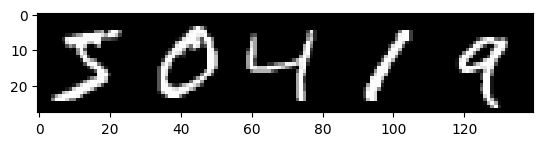

In [31]:
plt.imshow(train_5ten,cmap='gray')

In [33]:
np.random.random((28,28)).shape

(28, 28)

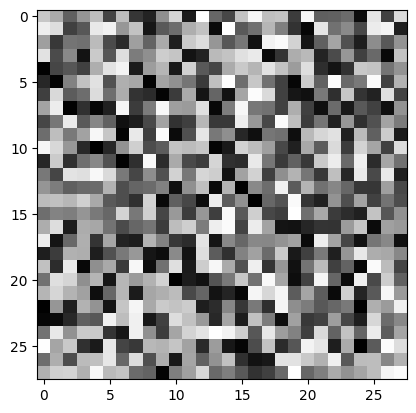

In [35]:
plt.imshow(np.random.random((28,28)),cmap='gray')

In [36]:
np.random.normal(0,0.1,1)

array([-0.01046918])

In [37]:
noisy_images = train_images[5] + np.random.normal(0,0.1,(28,28))

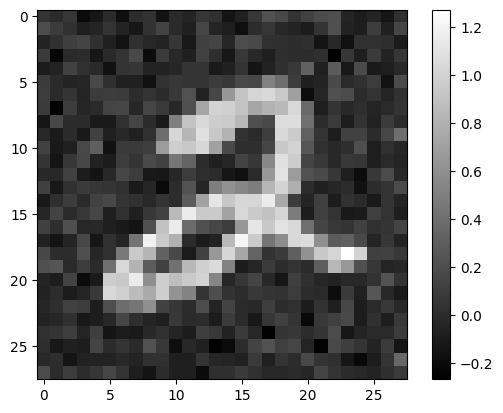

In [39]:
plt.imshow(noisy_images, cmap='gray')
plt.colorbar()

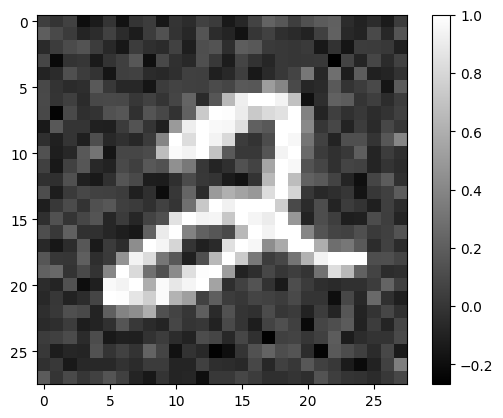

In [40]:
noisy_images[noisy_images > 1.0] = 1.0
plt.imshow(noisy_images, cmap='gray')
plt.colorbar()

In [42]:
train_noisy_images = train_images + np.random.normal(0.5, 0.1, train_images.shape)
train_noisy_images[train_noisy_images > 1.0] = 1.0

test_noisy_images = test_images + np.random.normal(0.5, 0.1, test_images.shape)
test_noisy_images[test_noisy_images > 1.0] = 1.0

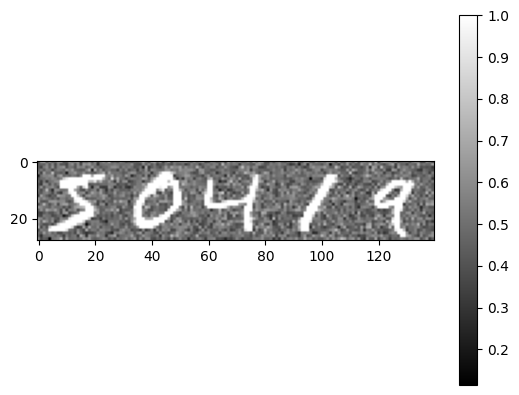

In [43]:
plt.imshow(train_noisy_images[:5].transpose( (1, 0, 2) ).reshape(28, -1), cmap="gray")
plt.colorbar()
plt.show()

In [50]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=64, num_classes=10):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size,
                          nonlinearity='tanh',batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out,h_n = self.rnn(x)
        last = out[:,-1,:]
        logits = self.fc(last)
        return logits
model = SimpleRNNClassifier().to(device)

In [53]:
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total params:", total_params)
print("Trainable params:", trainable_params)

SimpleRNNClassifier(
  (rnn): RNN(28, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)
Total params: 6666
Trainable params: 6666


In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [56]:
X_train = torch.tensor(train_noisy_images, dtype=torch.float32)   # (N, 28, 28)
y_train = torch.tensor(train_labels, dtype=torch.long)            # (N,)
X_test  = torch.tensor(test_noisy_images, dtype=torch.float32)
y_test  = torch.tensor(test_labels, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)

hist = {"accuracy": [], "loss": [], "val_accuracy": [], "val_loss": []}

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total

epochs = 5
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += xb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_loss, val_acc = evaluate(model, test_loader)

    hist["loss"].append(train_loss)
    hist["accuracy"].append(train_acc)
    hist["val_loss"].append(val_loss)
    hist["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

Epoch 1/5 - loss: 1.2748 - acc: 0.5424 - val_loss: 1.2088 - val_acc: 0.5877
Epoch 2/5 - loss: 1.1302 - acc: 0.6061 - val_loss: 1.1459 - val_acc: 0.6070
Epoch 3/5 - loss: 0.9734 - acc: 0.6670 - val_loss: 0.8239 - val_acc: 0.7235
Epoch 4/5 - loss: 0.7642 - acc: 0.7442 - val_loss: 0.7753 - val_acc: 0.7449
Epoch 5/5 - loss: 0.6265 - acc: 0.7989 - val_loss: 0.6184 - val_acc: 0.7991


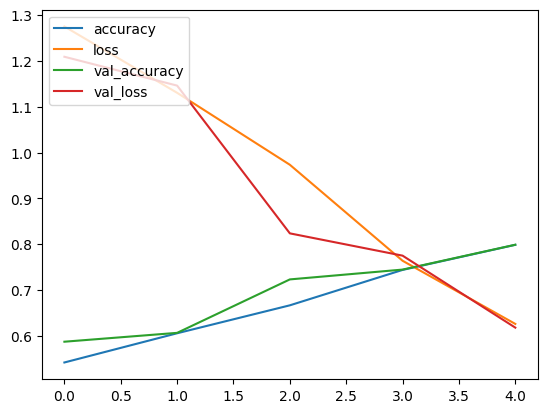

In [59]:
plt.plot(hist["accuracy"], label="accuracy")
plt.plot(hist["loss"], label="loss")
plt.plot(hist["val_accuracy"], label="val_accuracy")
plt.plot(hist["val_loss"], label="val_loss")
plt.legend(loc="upper left")
plt.show()

In [60]:
model.eval()
with torch.no_grad():
    xb = torch.tensor(test_noisy_images[3:4], dtype=torch.float32).to(device)  # (1,28,28)
    logits = model(xb)
    res = torch.softmax(logits, dim=1).cpu().numpy()
res.shape

(1, 10)

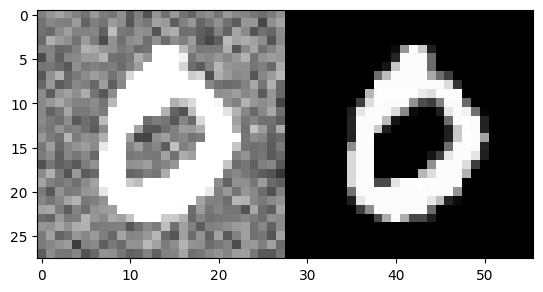

In [61]:
plt.imshow(   np.concatenate([test_noisy_images[3], test_images[3]], axis=1) , cmap="gray")
plt.show()

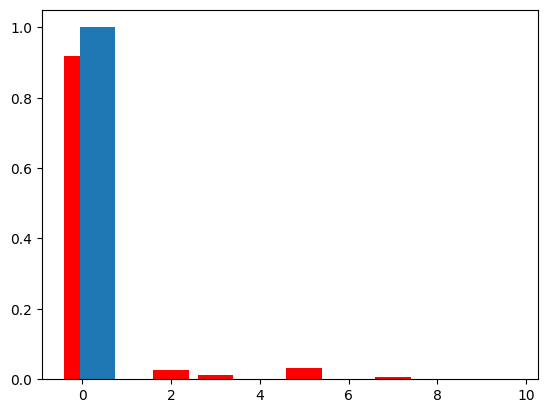

In [62]:
plt.bar(range(10), res[0], color='red')
plt.bar(np.array(range(10)) + 0.35, np.eye(10)[test_labels[3]])
plt.show()
